In [1]:
from synaptic_tomo_tools.activezone import (
    import_membrane_segmentations_from_glb, 
    find_active_zones_from_glb, 
    define_active_zonogram, 
    extract_active_zonogram, 
    transform_coordinates_to_active_zonogram
)
from synaptic_tomo_tools.packing_density import calculate_packing_density_using_sliding_cylinder
from matplotlib import pyplot as plt
import numpy as np
from pathlib import Path
import starfile


In [2]:
tomo_path = "/goliath/processing/Gouaux/CJS/BestTomo/ProcessingCJS/tomograms/15F1/TOP_TOMOS/20241030_AMmilled12-1_15"


In [3]:
membranes_glb = import_membrane_segmentations_from_glb(tomo_path)
active_zones_glb = find_active_zones_from_glb(membranes_glb)
active_zonograms = define_active_zonogram(active_zones_glb)
transformed_tomo = extract_active_zonogram(active_zonograms=active_zonograms, active_zones=active_zones_glb, tomo_path=tomo_path,tomo_type='ddw')

Presynaptic membrane 1 volume: 0.000915 µm³ (576291 vertices, 1152320 faces)
Presynaptic membrane 2 volume: 0.001111 µm³ (652482 vertices, 1304964 faces)
Postsynaptic membrane 1 volume: 0.001185 µm³ (721748 vertices, 1443496 faces)
Found active zone: active_zone_pre1_post1 with 111280 presynaptic and 101361 postsynaptic points
Found active zone: active_zone_pre2_post1 with 94263 presynaptic and 181591 postsynaptic points
Defining active zonogram
Rendering active zonogram


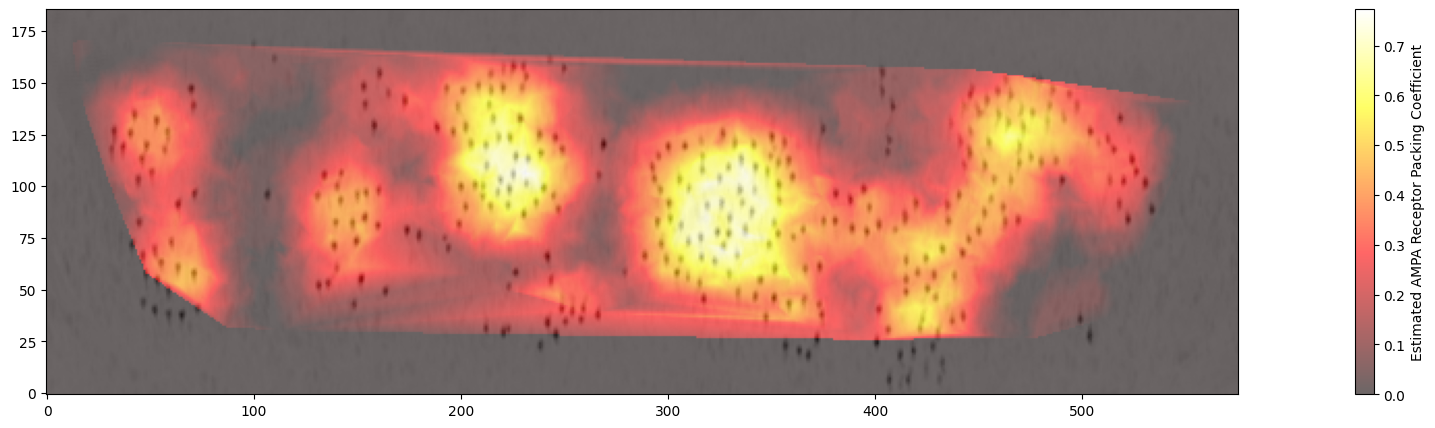

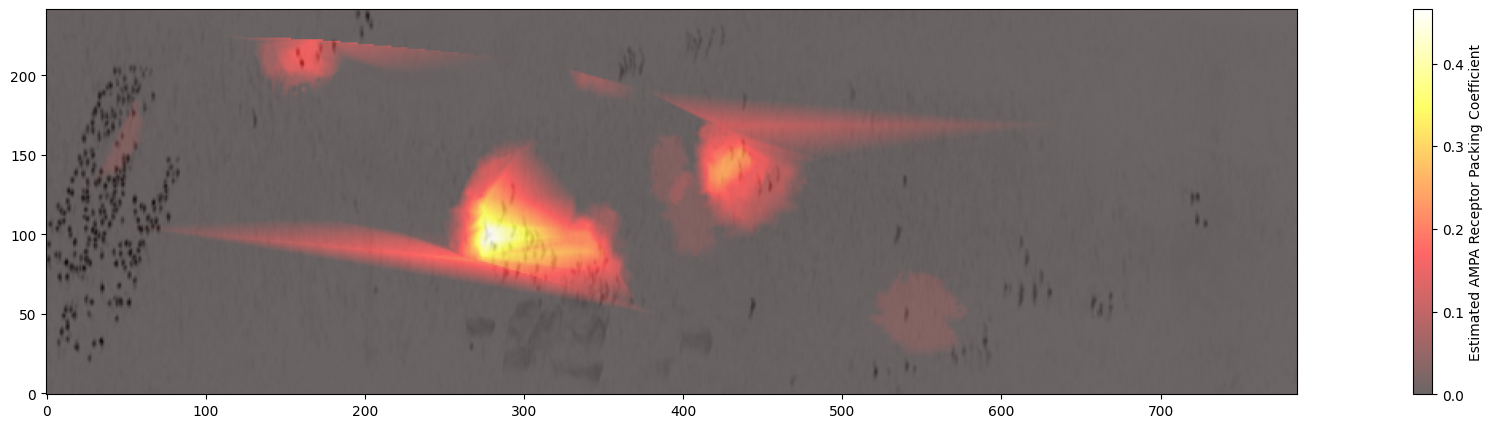

In [4]:
for i, az in enumerate(active_zones_glb['active_zones']):
    az_name = az
    active_zone = active_zones_glb['active_zones'][az_name]
    azonogram = active_zonograms['zonogram_data'][az_name]
    
    aunps = starfile.read(Path(tomo_path) / "best_alignment" / "aunps" / f"aunp_tm_BP_active_zone_{i}.star")
    v_co, density = calculate_packing_density_using_sliding_cylinder(active_zone, azonogram, aunps[['faCoordinateX', 'faCoordinateY', 'faCoordinateZ']].to_numpy())
    t_v = transform_coordinates_to_active_zonogram(v_co, active_zonograms['zonogram_data'][az_name])
    plt.figure(figsize=(30,5))
    plt.imshow(np.min(transformed_tomo['rendered_zonograms'][az_name]['transformed_tomogram'], axis=0), cmap='gray',origin='lower')
    # Interpolate every pixel on density_map between centers and assign packing_coefficient values
    tomo_shape = transformed_tomo['rendered_zonograms'][az_name]['transformed_tomogram'].shape
    from scipy.interpolate import griddata
    grid_x, grid_y = np.mgrid[0:tomo_shape[1], 0:tomo_shape[2]]
    density_map = griddata(t_v[:,:2], density, (grid_y, grid_x), method='linear', fill_value=0)
    plt.imshow(density_map, cmap='hot', alpha=0.6, origin='lower')
    plt.colorbar(label='Estimated AMPA Receptor Packing Coefficient')
    plt.show()

    

: 

: 